# Visual Diagnostics, Relationship Analysis, and Data Transformation



In [ ]:
# Imports

from pathlib import Path
import re
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
# Load and consolidate yearly cleaned datasets

data_dir = Path("../cleaned_data")
csv_paths = sorted(
    data_dir.glob("data_*.csv"),
    key=lambda p: int(re.search(r"(\d{4})", p.stem).group(1))
)

frames = []
for p in csv_paths:
    year = int(re.search(r"(\d{4})", p.stem).group(1))
    df = pd.read_csv(p)
    df["YEAR"] = year
    frames.append(df)

consolidated_df = pd.concat(frames, ignore_index=True, sort=False)
print(f"Loaded {len(csv_paths)} files")
print(f"Consolidated shape: {consolidated_df.shape}")
consolidated_df.head()

Loaded 20 files
Consolidated shape: (739544, 24)


,AREA,ST,STATE,OCC_CODE,OCC_TITLE,GROUP,TOT_EMP,EMP_PRSE,MEAN_PRSE,H_MEAN,...,H_PCT90,A_MEAN,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY,YEAR
0,1,AL,Alabama,11-0000,Management occupations,major,79730.0,1.2,0.6,37.12,...,66.8,77210.0,33340.0,47420.0,67370.0,94600.0,138950.0,NaN,NaN,2005
1,1,AL,Alabama,11-1011,Chief executives,NaN,3300.0,4.0,1.6,63.63,...,NaN,132350.0,47060.0,83380.0,133940.0,NaN,NaN,NaN,NaN,2005
2,1,AL,Alabama,11-1021,General and operations managers,NaN,27450.0,1.4,0.8,41.57,...,NaN,86460.0,36100.0,48620.0,71630.0,110380.0,NaN,NaN,NaN,2005
3,1,AL,Alabama,11-1031,Legislators,NaN,1730.0,15.7,3.7,NaN,...,NaN,14700.0,11330.0,11950.0,12980.0,14010.0,20430.0,True,NaN,2005
4,1,AL,Alabama,11-2011,Advertising and promotions managers,NaN,370.0,8.0,5.9,29.47,...,60.09,61290.0,26740.0,34030.0,48080.0,72970.0,124990.0,NaN,NaN,2005


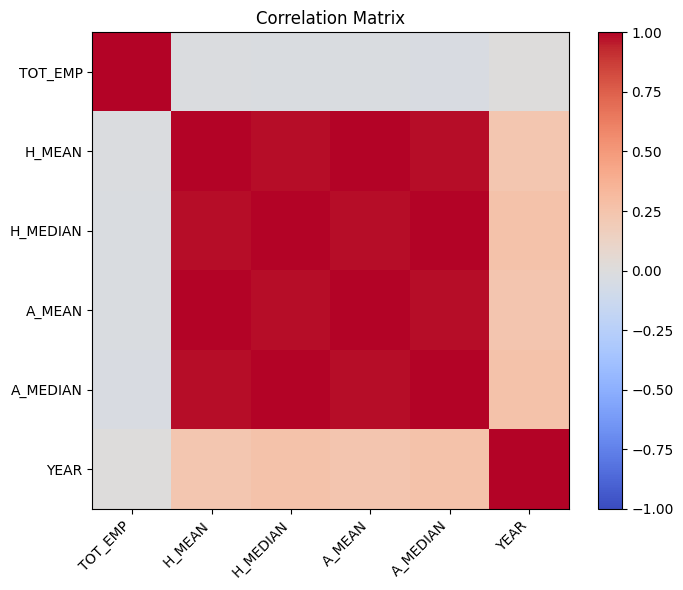

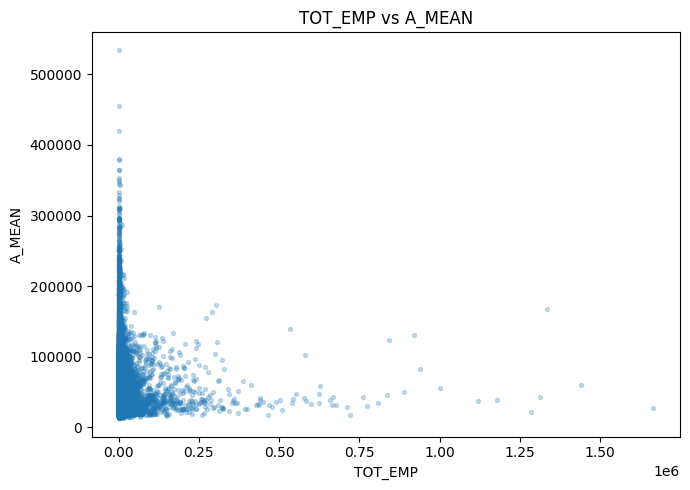

In [ ]:
# Analyze feature relationships with correlation and scatter plots

numeric_candidates = [
    "TOT_EMP", "EMP_PRSE", "MEAN_PRSE",
    "H_MEAN", "H_PCT10", "H_PCT25", "H_MEDIAN", "H_PCT75", "H_PCT90",
    "A_MEAN", "A_PCT10", "A_PCT25", "A_MEDIAN", "A_PCT75", "A_PCT90",
    "YEAR"
]

for col in numeric_candidates:
    if col in consolidated_df.columns:
        consolidated_df[col] = pd.to_numeric(consolidated_df[col], errors="coerce")

rel_cols = [c for c in ["TOT_EMP", "H_MEAN", "H_MEDIAN", "A_MEAN", "A_MEDIAN", "YEAR"] if c in consolidated_df.columns]
corr = consolidated_df[rel_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Correlation Matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

if {"TOT_EMP", "A_MEAN"}.issubset(consolidated_df.columns):
    sample = consolidated_df[["TOT_EMP", "A_MEAN"]].dropna()
    if len(sample) > 25000:
        sample = sample.sample(25000, random_state=42)
    plt.figure(figsize=(7, 5))
    plt.scatter(sample["TOT_EMP"], sample["A_MEAN"], s=8, alpha=0.25)
    plt.xlabel("TOT_EMP")
    plt.ylabel("A_MEAN")
    plt.title("TOT_EMP vs A_MEAN")
    plt.tight_layout()
    plt.show()

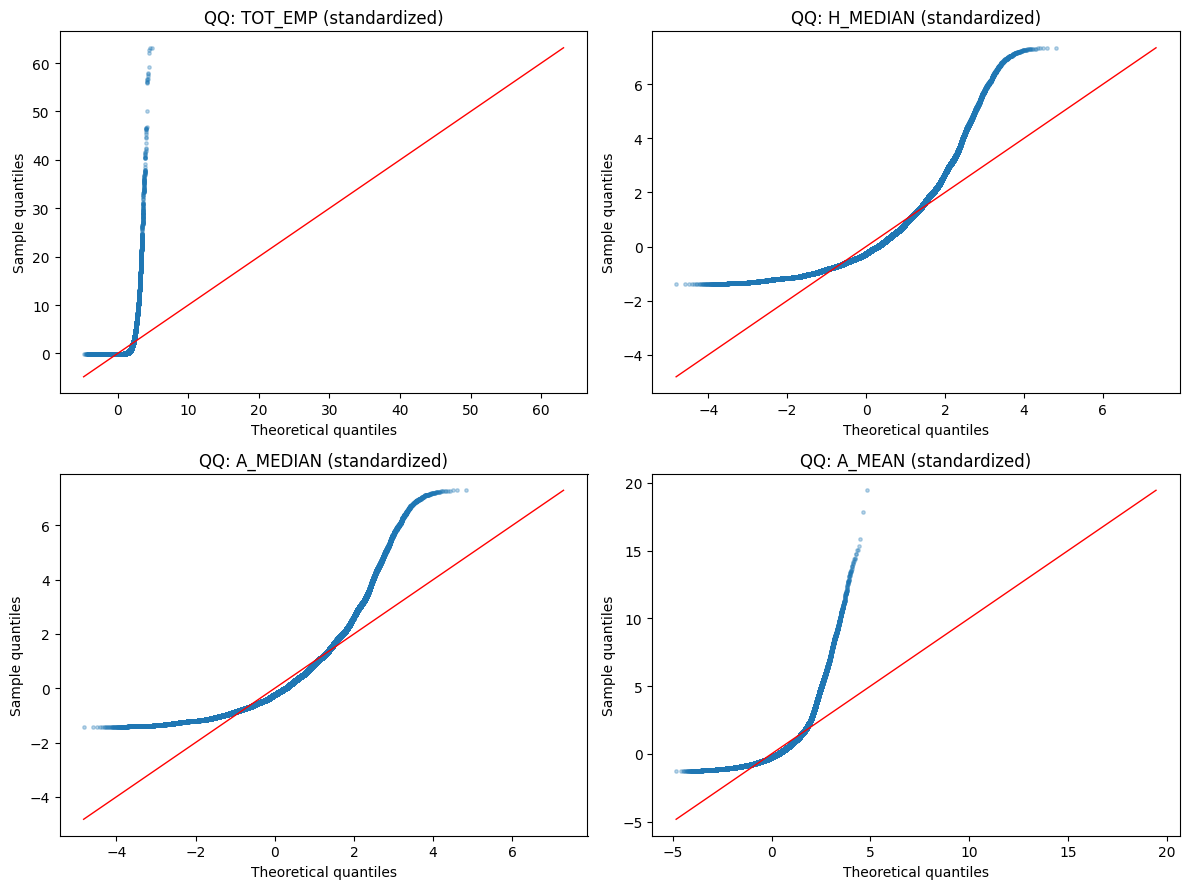

In [ ]:
# Build QQ plots to assess normality of standardized features

def qq_plot(ax, series, title):
    s = series.dropna().to_numpy()
    if s.size < 10:
        ax.set_title(f"{title} (insufficient data)")
        ax.axis("off")
        return
    s = np.sort(s)
    p = (np.arange(1, s.size + 1) - 0.5) / s.size
    q = np.array([NormalDist().inv_cdf(v) for v in p])
    ax.scatter(q, s, s=6, alpha=0.3)
    lo = min(q.min(), s.min())
    hi = max(q.max(), s.max())
    ax.plot([lo, hi], [lo, hi], color="red", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Sample quantiles")

diag_cols = [c for c in ["TOT_EMP", "H_MEDIAN", "A_MEDIAN", "A_MEAN"] if c in consolidated_df.columns]
diag_df = consolidated_df[diag_cols].copy()
diag_df = diag_df.apply(lambda x: (x - x.mean()) / x.std(ddof=0))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()
for i, col in enumerate(diag_cols[:4]):
    qq_plot(axes[i], diag_df[col], f"QQ: {col} (standardized)")
for j in range(len(diag_cols), 4):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Apply log transform and z-score normalization for modeling

transform_cols = [c for c in ["TOT_EMP", "H_MEDIAN", "A_MEDIAN", "A_MEAN"] if c in consolidated_df.columns]
model_df = consolidated_df[["YEAR", *transform_cols]].copy()

for col in transform_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

for col in transform_cols:
    model_df[f"log1p_{col}"] = np.log1p(model_df[col].clip(lower=0))

log_cols = [f"log1p_{c}" for c in transform_cols]
for col in log_cols:
    mu = model_df[col].mean()
    sigma = model_df[col].std(ddof=0)
    if pd.notna(sigma) and sigma > 0:
        model_df[f"z_{col}"] = (model_df[col] - mu) / sigma
    else:
        model_df[f"z_{col}"] = np.nan

z_cols = [f"z_{c}" for c in log_cols]
model_ready_df = model_df.dropna(subset=z_cols).reset_index(drop=True)

save_path = data_dir / "model_ready_transformed.csv"
model_ready_df.to_csv(save_path, index=False)
print(f"Model-ready shape: {model_ready_df.shape}")
print(f"Saved: {save_path}")
model_ready_df.head()

Model-ready shape: (646927, 13)
Saved: ../cleaned_data/model_ready_transformed.csv


,YEAR,TOT_EMP,H_MEDIAN,A_MEDIAN,A_MEAN,log1p_TOT_EMP,log1p_H_MEDIAN,log1p_A_MEDIAN,log1p_A_MEAN,z_log1p_TOT_EMP,z_log1p_H_MEDIAN,z_log1p_A_MEDIAN,z_log1p_A_MEAN
0,2005,79730.0,32.39,67370.0,77210.0,11.286414,3.508256,11.117970,11.254297,2.400146,0.931144,0.883863,0.971952
1,2005,3300.0,64.39,133940.0,132350.0,8.101981,4.180369,11.805155,11.793213,0.675922,2.411972,2.324001,2.058830
2,2005,27450.0,34.44,71630.0,86460.0,10.220158,3.567841,11.179283,11.367449,1.822818,1.062423,1.012358,1.200154
3,2005,370.0,23.12,48080.0,61290.0,5.916202,3.183041,10.780642,11.023388,-0.507577,0.214616,0.176924,0.506257
4,2005,1300.0,33.55,69770.0,78040.0,7.170888,3.542408,11.152974,11.264990,0.171778,1.006387,0.957221,0.993516


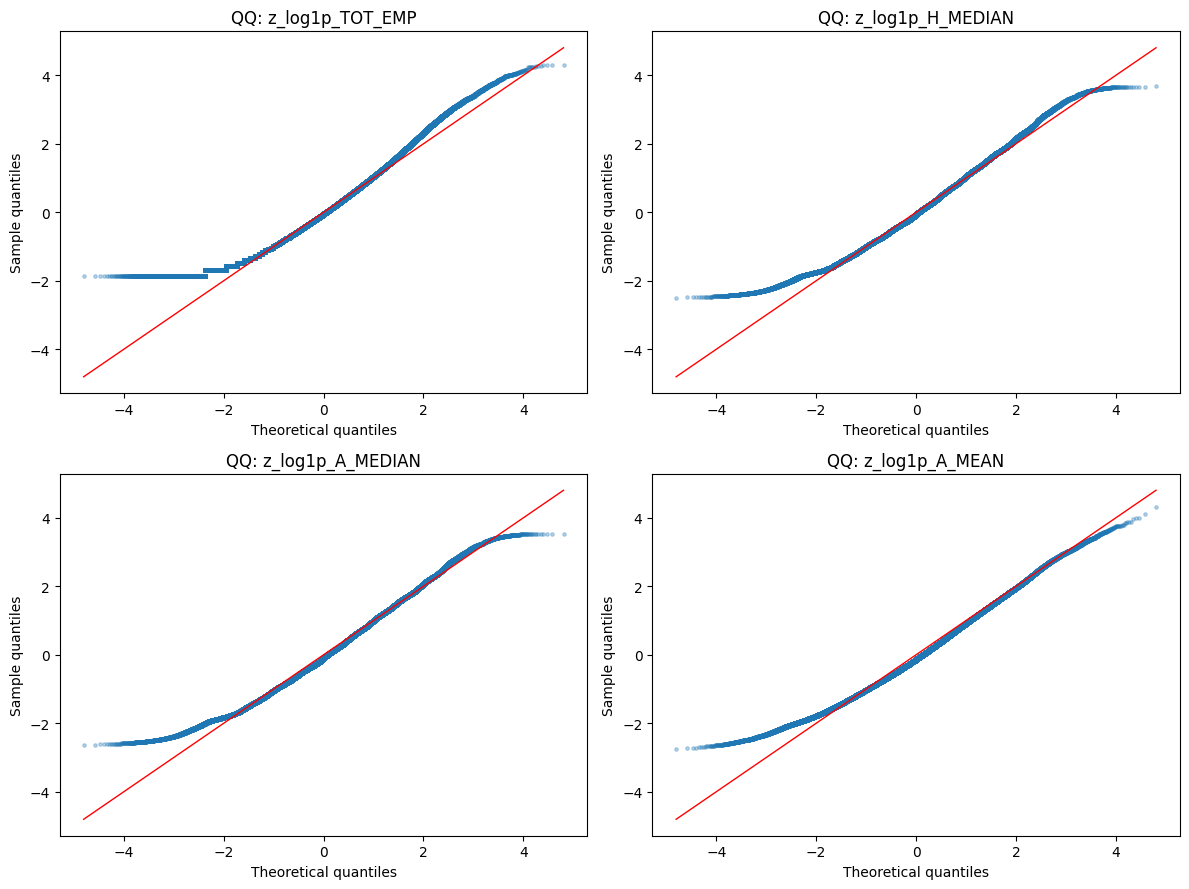

In [ ]:
# Re-check normality on transformed and normalized features

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()
for i, col in enumerate(z_cols[:4]):
    qq_plot(axes[i], model_ready_df[col], f"QQ: {col}")
for j in range(len(z_cols), 4):
    axes[j].axis("off")
plt.tight_layout()
plt.show()